In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
import pandas as pd

# Load the dataset with correct encoding
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# First look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Check data types and missing values
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Convert dates to proper format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful columns from date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

# Verify
print(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Month Name']].head())
print("\nDate types:")
print(df[['Order Date', 'Ship Date']].dtypes)

  Order Date  Ship Date  Year  Month Month Name
0 2016-11-08 2016-11-11  2016     11   November
1 2016-11-08 2016-11-11  2016     11   November
2 2016-06-12 2016-06-16  2016      6       June
3 2015-10-11 2015-10-18  2015     10    October
4 2015-10-11 2015-10-18  2015     10    October

Date types:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [7]:
# Remove columns we don't need for analysis
df = df.drop(columns=['Row ID', 'Country', 'Product ID', 'Customer ID', 'Postal Code'])

# Verify final dataset
print("Final Shape:", df.shape)
print("\nFinal Columns:", df.columns.tolist())

Final Shape: (9994, 19)

Final Columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name']


C:\Users\Unnati Yadav\AppData\Local\Temp\ipykernel_9824\1077637667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_r')


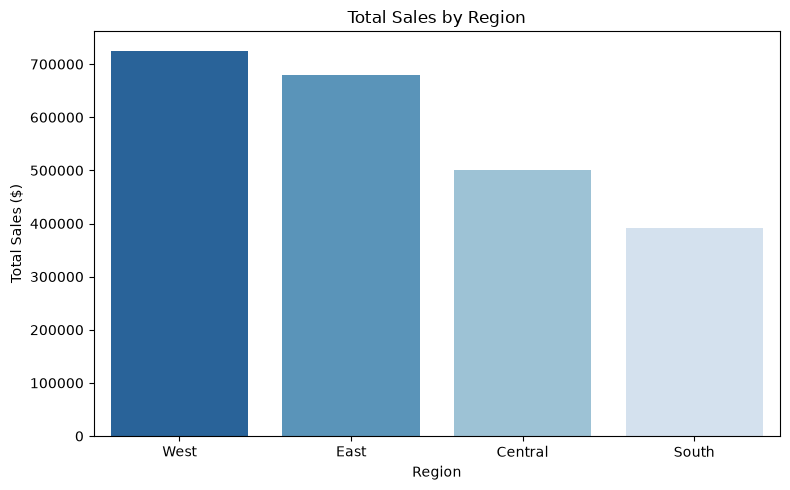

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_r')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\Unnati Yadav\AppData\Local\Temp\ipykernel_9824\3590098635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')


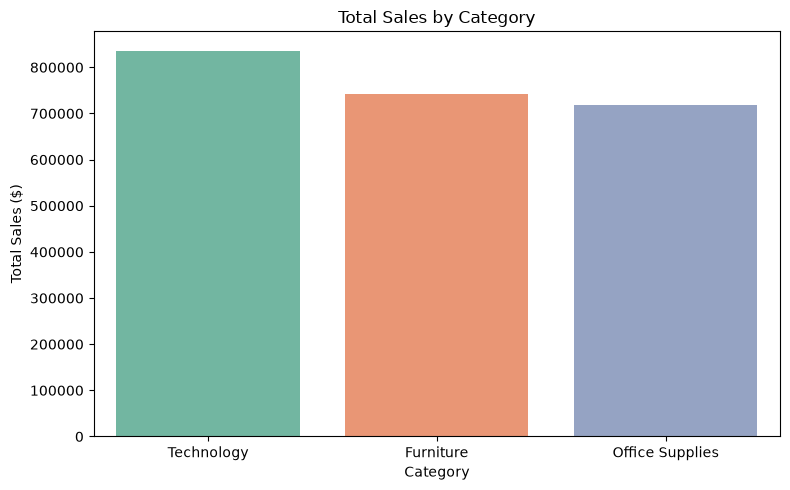

In [10]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\Unnati Yadav\AppData\Local\Temp\ipykernel_9824\983382946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='Set2')


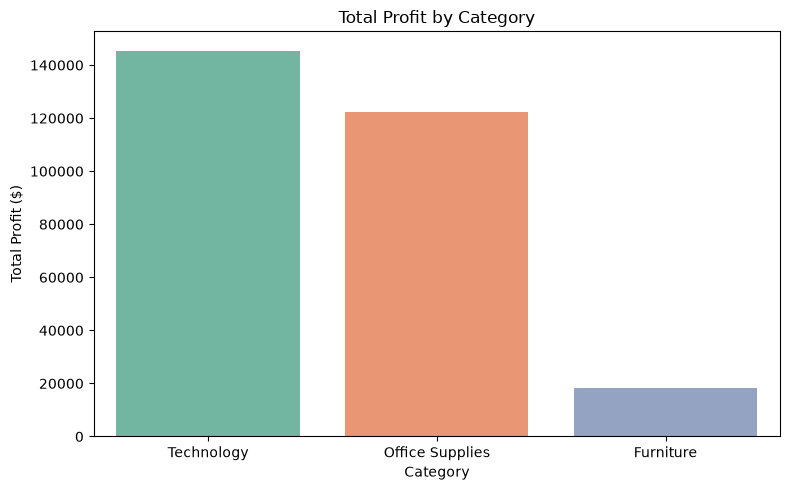

In [11]:
# Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='Set2')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

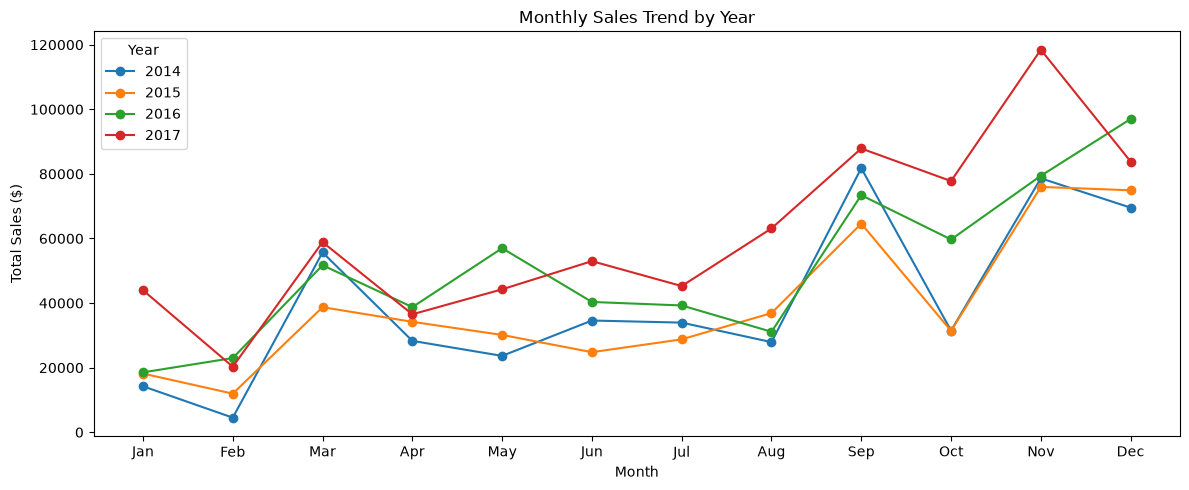

In [12]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,5))
for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.legend(title='Year')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

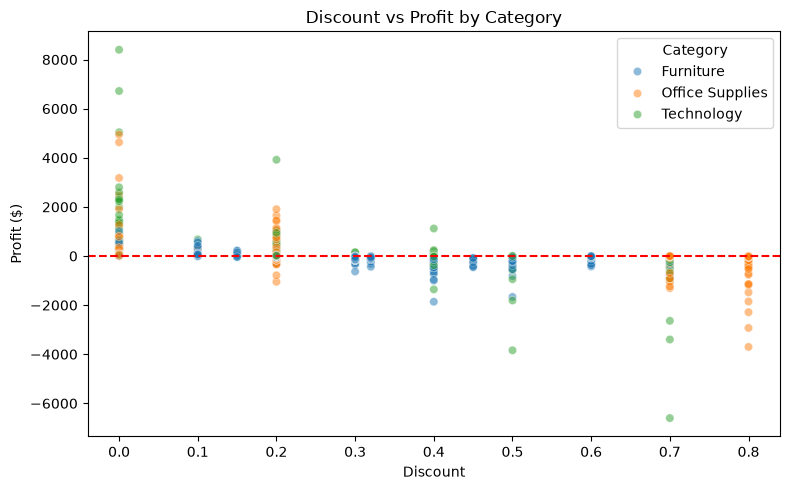

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', 
                hue='Category', alpha=0.5)
plt.title('Discount vs Profit by Category')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--', label='Break-even')
plt.tight_layout()
plt.show()